## Importing libraries

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions



## Data Preprocessing

### Training Image preprocessing

In [2]:
import tensorflow as tf

training_set = tf.keras.utils.image_dataset_from_directory(
    r'D:\flask\flask_project\Data\Processed_Data\train',  # Updated path
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

print("✅ Training dataset loaded successfully!")


Found 228 files belonging to 3 classes.
✅ Training dataset loaded successfully!


### Validation Image Preprocessing

In [3]:
import tensorflow as tf

validation_set = tf.keras.utils.image_dataset_from_directory(
    r'D:\flask\flask_project\Data\Processed_Data\val',  # Corrected path
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

print("✅ Validation dataset loaded successfully!")


Found 48 files belonging to 3 classes.


✅ Validation dataset loaded successfully!


#### To avoid Overshooting Loss function
1. Choose small learning rate default 0.001 here we have taken 0.0001
2. There may be chance of underfitting so increase number of neuron
3. Add more Convolutional Layer to extract more feature from images there may be possibilty that model unable to capture relevant feature or model is confusing due to lack of feature so feed with more feature

## Building Model

In [4]:
cnn = tf.keras.models.Sequential()

### Building Convolution Layer

In [5]:
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

c:\Users\Saranya Reddy\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [7]:
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [8]:
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [9]:
cnn.add(tf.keras.layers.Conv2D(filters=512, kernel_size=3, padding='same', activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=512, kernel_size=3, padding='same', activation='relu'))  # Fixed: Added padding='same'
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

In [10]:
cnn.add(tf.keras.layers.Dropout(0.25))  

In [11]:
cnn.add(tf.keras.layers.Flatten())

In [12]:
cnn.add(tf.keras.layers.Dense(units=1500,activation='relu'))

In [13]:
cnn.add(tf.keras.layers.Dropout(0.5))

In [14]:
cnn.add(tf.keras.layers.Dense(units=3, activation='softmax'))

### Compiling and Training Phase

In [15]:
cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
            loss='categorical_crossentropy',
            metrics=['accuracy'])

In [16]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     6,913,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         4,503 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,630,227 (44.37 MB)

 Trainable params: 11,630,227 (44.37 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
training_history = cnn.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.2948 - loss: 4.2196 - val_accuracy: 0.3750 - val_loss: 1.0828
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.4410 - loss: 1.0630 - val_accuracy: 0.4583 - val_loss: 1.0294
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.4822 - loss: 1.0195 - val_accuracy: 0.5208 - val_loss: 0.9083
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 980ms/step - accuracy: 0.5925 - loss: 0.9076 - val_accuracy: 0.6042 - val_loss: 0.8109
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 944ms/step - accuracy: 0.6476 - loss: 0.8108 - val_accuracy: 0.6875 - val_loss: 0.7425
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 959ms/step - accuracy: 0.6454 - loss: 0.7334 - val_accuracy: 0.6458 - val_loss: 0.6951
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 969ms/step - accuracy: 0.7067 - loss: 0.6780 - val_accuracy: 0.7292 - val_loss: 0.7192
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 999ms/step - accuracy: 0.7890 - loss: 0.5666 - val_accuracy: 0.5417 - val_loss: 0.9220

## Evaluating Model

In [18]:
#Training set Accuracy
train_loss, train_acc = cnn.evaluate(training_set)
print('Training accuracy:', train_acc)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 215ms/step - accuracy: 0.8654 - loss: 0.3987
Training accuracy: 0.8421052694320679


In [19]:
#Validation set Accuracy
val_loss, val_acc = cnn.evaluate(validation_set)
print('Validation accuracy:', val_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.7014 - loss: 0.6071
Validation accuracy: 0.7083333134651184


### Saving Model

In [20]:
cnn.save('accident_severity_model.keras')


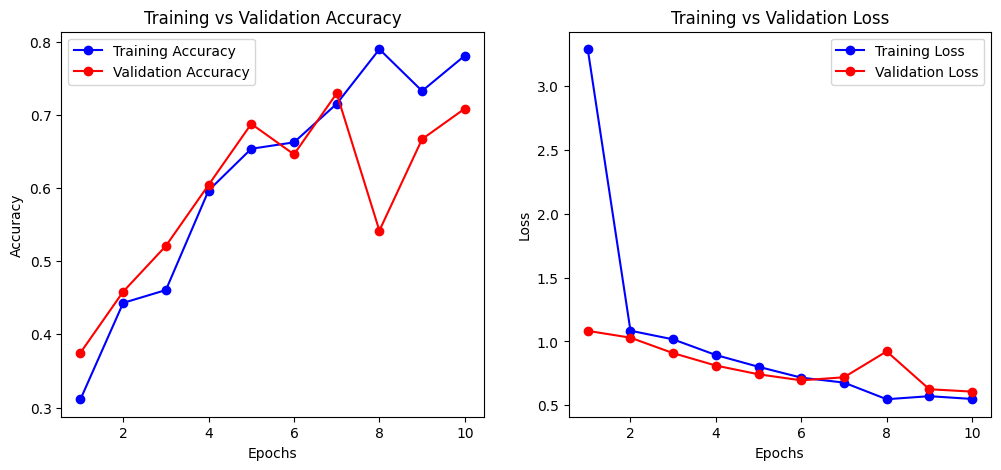

In [21]:
import matplotlib.pyplot as plt

# Extract values from the training history
acc = training_history.history['accuracy']
val_acc = training_history.history['val_accuracy']
loss = training_history.history['loss']
val_loss = training_history.history['val_loss']
epochs = range(1, len(acc) + 1)

# Plot Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Show plots
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step


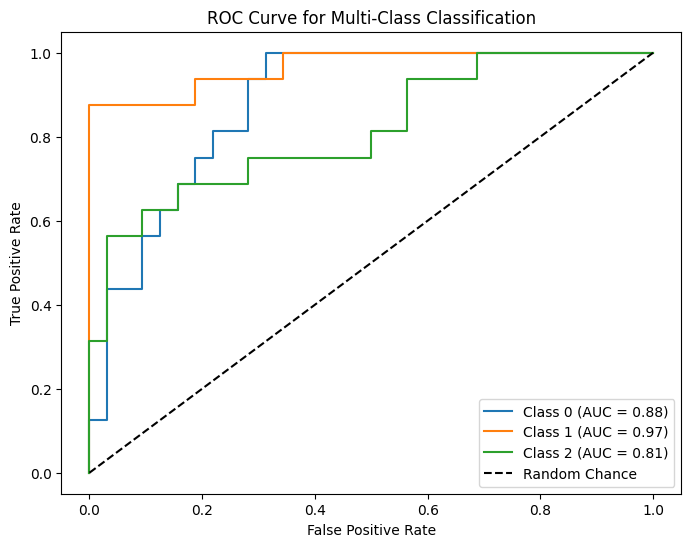

In [22]:
from sklearn.metrics import roc_curve, auc
import numpy as np
import tensorflow as tf

# Get true labels and predicted probabilities
y_true = []
y_pred_prob = []

for images, labels in validation_set:  # Iterate through dataset
    y_true.extend(tf.argmax(labels, axis=1).numpy())  # Convert one-hot to class index
    y_pred_prob.extend(cnn.predict(images))  # Get predictions

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)

# Compute ROC curve for each class
n_classes = y_pred_prob.shape[1]
fpr, tpr, roc_auc = {}, {}, {}

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true == i, y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

# Plot settings
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multi-Class Classification')
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
Classification Report:

              precision    recall  f1-score   support

        Hand       0.56      0.88      0.68        16
        Head       1.00      0.62      0.77        16
         Leg       0.77      0.62      0.69        16

    accuracy                           0.71        48
   macro avg       0.78      0.71      0.71        48
weighted avg       0.78      0.71      0.71        48



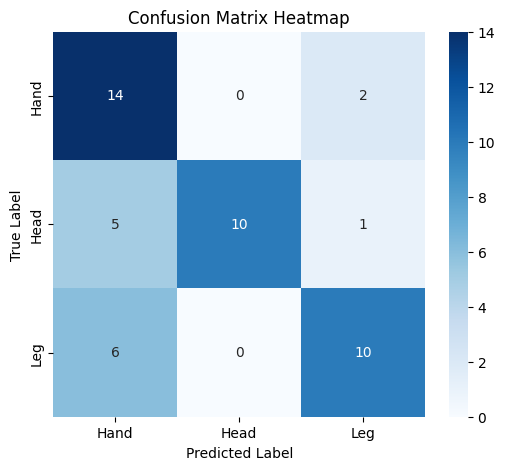

In [23]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Extract true labels and predicted labels
y_true = []
y_pred = []

for images, labels in validation_set:  # Iterate through dataset
    y_true.extend(tf.argmax(labels, axis=1).numpy())  # Convert one-hot to class index
    predictions = cnn.predict(images)  # Get predictions
    y_pred.extend(np.argmax(predictions, axis=1))  # Convert probabilities to class index

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
class_names = ['Hand', 'Head', 'Leg']  # Adjust based on your dataset

# Print classification report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


In [29]:
import pandas as pd

class_acc = cm.diagonal() / cm.sum(axis=1)  # Compute per-class accuracy
df = pd.DataFrame({'Class': class_names, 'Accuracy': class_acc})

plt.figure(figsize=(8, 5))
sns.barplot(x='Class', y='Accuracy', data=df, palette="viridis")
plt.ylim(0, 1)
plt.title("Class-wise Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Class")
plt.show()
"""


SyntaxError: incomplete input (445098125.py, line 13)